In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import UnitaryGate
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
# from qiskit_aer.noise import NoiseModel

import numpy as np

import matplotlib.pyplot as plt

In [2]:
service = QiskitRuntimeService()
backend = service.backend("ibm_kyiv")

simulator = AerSimulator.from_backend(backend)
# simulator.set_option("seed_simulator", 42)
# simulator = AerSimulator(noise_model=NoiseModel.from_backend(backend))

In [3]:
def construct_gate(alpha):
    matrix = np.matrix([[np.cos(alpha), -np.sin(alpha)], [np.sin(alpha), np.cos(alpha)]])
    return UnitaryGate(matrix)

In [4]:
NUM_QUBITS = 1
SHOTS = 1000000

def generate_results(alpha):
    circ = QuantumCircuit(NUM_QUBITS)
    for i in range(NUM_QUBITS):
        circ.append(construct_gate(alpha), [i])
    circ.measure_all()

    circ = transpile(circ, simulator)
    result = simulator.run(circ, shots=SHOTS).result()
    counts = result.get_counts(circ)

    count_1 = 0
    total = 0

    for r, n in counts.items():
        num_1 = sum([1 if x == "1" else 0 for x in r])
        count_1 += num_1 * n
        total += n * NUM_QUBITS

    return count_1 / total

In [5]:
alphas = []
absolute_err_of_mean = []

min_err = 999
best_alpha = 0

for angle in np.arange(np.pi / 4 - 0.01, np.pi / 4 + 0.01, 0.00005):
    alphas.append(angle)
    mean = generate_results(angle)
    err = abs(0.5 - mean)
    absolute_err_of_mean.append(err)

    if err < min_err:
        min_err = err
        best_alpha = angle
    

Best Alpha Found: 0.785498 (error: 0.000030)


(0.0, 0.010889000000000038)

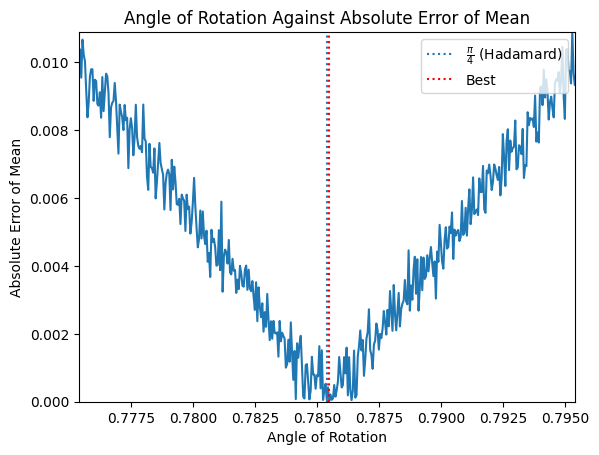

In [6]:
print("Best Alpha Found: %f (error: %f)" % (best_alpha, min_err))

plt.plot(alphas, absolute_err_of_mean)
plt.title("Angle of Rotation Against Absolute Error of Mean")
plt.xlabel("Angle of Rotation")
plt.ylabel("Absolute Error of Mean")

plt.axvline(x=np.pi / 4, linestyle="dotted", label="$\\frac{\\pi}{4}$ (Hadamard)")
plt.axvline(x=best_alpha, linestyle="dotted", color="red", label="Best")

plt.legend(loc="upper right")

plt.xlim((min(alphas), max(alphas)))
plt.ylim((0, max(absolute_err_of_mean)))